# T2 — Análisis Exploratorio y Plan Algorítmico

**Proyecto:** Predicción de la Resistencia a Compresión del Concreto mediante Machine Learning
**Curso:** Aplicaciones de IA en Estructuras
**Dataset:** Concrete Compressive Strength (UCI Machine Learning Repository)

Este notebook ejecuta de principio a fin: carga de datos, EDA, entrenamiento con
validación cruzada, evaluación con métricas exactas (R², RMSE, MAE), comparación
contra el método empírico ACI 211.1, y análisis de interpretabilidad (SHAP).

Todos los resultados que aparecen en el informe T2 (tablas, figuras, métricas)
se generan directamente desde este notebook — no están escritos a mano.

## 0. Imports y configuración

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Crea la carpeta de figuras si no existe (evita FileNotFoundError al guardar plots)
os.makedirs("../docs/figures", exist_ok=True)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga del dataset

**Nota:** el archivo original de UCI (`Concrete_Data.csv`) usa punto y coma (`;`) como
separador, no coma. Por eso se especifica `sep=";"` al leerlo. Además se renombran
las columnas (los nombres originales incluyen unidades y paréntesis, poco prácticos
para el código).

In [2]:
df = pd.read_csv("../data/raw/Concrete_Data.csv", sep=";")

df.columns = [
    "Cement", "BlastFurnaceSlag", "FlyAsh", "Water", "Superplasticizer",
    "CoarseAggregate", "FineAggregate", "Age", "CompressiveStrength"
]

print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones: 1030 filas x 9 columnas


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2. Análisis Exploratorio de Datos (EDA)

### 2.1 Calidad de datos: nulos y duplicados

In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())
print(f"\nTotal de valores nulos: {df.isna().sum().sum()}")
print(f"Filas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
Cement                 0
BlastFurnaceSlag       0
FlyAsh                 0
Water                  0
Superplasticizer       0
CoarseAggregate        0
FineAggregate          0
Age                    0
CompressiveStrength    0
dtype: int64

Total de valores nulos: 0
Filas duplicadas: 25


### 2.2 Estadística descriptiva

In [4]:
desc = df.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
BlastFurnaceSlag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
FlyAsh,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
Water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
Superplasticizer,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
CoarseAggregate,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
FineAggregate,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
Age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
CompressiveStrength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


### 2.3 Matriz de correlación

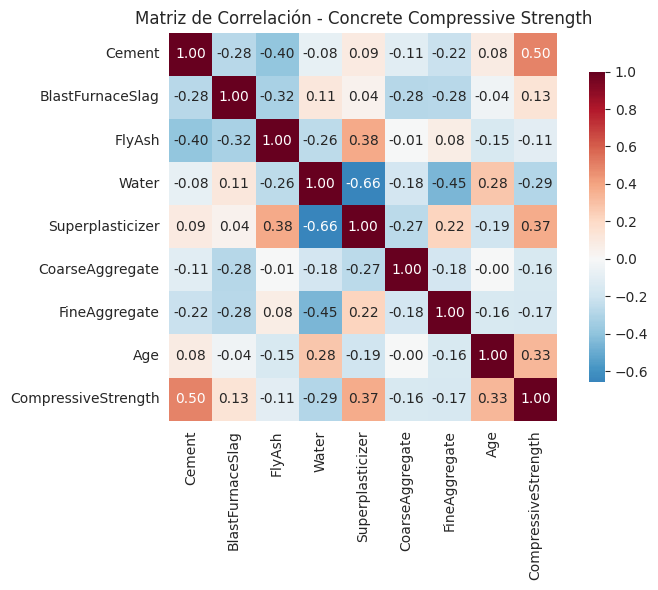

In [5]:
corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlación - Concrete Compressive Strength")
plt.tight_layout()
plt.savefig("../docs/figures/corr_heatmap.png", dpi=150)
plt.show()

In [6]:
corr["CompressiveStrength"].sort_values(ascending=False)

CompressiveStrength    1.000000
Cement                 0.497832
Superplasticizer       0.366079
Age                    0.328873
BlastFurnaceSlag       0.134829
FlyAsh                -0.105755
CoarseAggregate       -0.164935
FineAggregate         -0.167241
Water                 -0.289633
Name: CompressiveStrength, dtype: float64

### 2.4 Distribución de variables clave

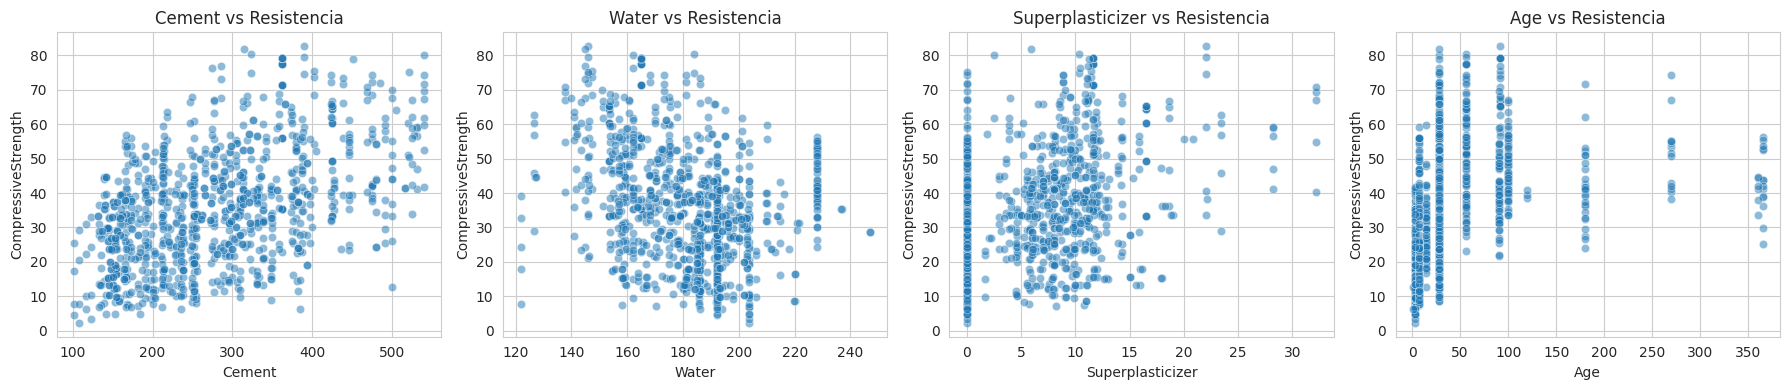

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, ["Cement", "Water", "Superplasticizer", "Age"]):
    sns.scatterplot(data=df, x=col, y="CompressiveStrength", ax=ax, alpha=0.5)
    ax.set_title(f"{col} vs Resistencia")
plt.tight_layout()
plt.savefig("../docs/figures/scatter_key_vars.png", dpi=150)
plt.show()

## 3. Separación de variables y protocolo de validación

- **Holdout 80/20**, `random_state=42` fijo y reportado para reproducibilidad.
- **5-fold Cross-Validation** sobre el conjunto de entrenamiento, usado únicamente
  para seleccionar hiperparámetros (no toca el conjunto de prueba).

In [8]:
X = df.drop(columns=["CompressiveStrength"])
y = df["CompressiveStrength"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba:        {X_test.shape[0]} filas")

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Entrenamiento: 824 filas
Prueba:        206 filas


## 4. Random Forest — búsqueda de hiperparámetros (5-fold CV)

In [9]:
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    rf_param_grid,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)

print("Mejores hiperparámetros Random Forest:", rf_grid.best_params_)
rf_best = rf_grid.best_estimator_

Mejores hiperparámetros Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400}


## 5. XGBoost — búsqueda de hiperparámetros (5-fold CV)

In [10]:
xgb_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    xgb_param_grid,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
xgb_grid.fit(X_train, y_train)

print("Mejores hiperparámetros XGBoost:", xgb_grid.best_params_)
xgb_best = xgb_grid.best_estimator_

Mejores hiperparámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 400}


## 6. Evaluación sobre el conjunto de prueba (holdout)

Métricas calculadas **exclusivamente** sobre el 20% de prueba, que ningún modelo
vio durante el ajuste de hiperparámetros.

In [11]:
def evaluate(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    return {"Modelo": name, "R2": round(r2, 3), "RMSE (MPa)": round(rmse, 2), "MAE (MPa)": round(mae, 2)}

results = [
    evaluate(rf_best, X_test, y_test, "Random Forest"),
    evaluate(xgb_best, X_test, y_test, "XGBoost"),
]
results_df = pd.DataFrame(results)
results_df

,Modelo,R2,RMSE (MPa),MAE (MPa)
0,Random Forest,0.881,5.53,3.79
1,XGBoost,0.917,4.63,3.26


## 7. Comparación contra el método empírico normativo (ACI 211.1)

Se aproxima el enfoque empírico clásico basado en la relación agua/cemento
(Ley de Abrams), como línea base de comparación frente a los modelos de ML.

**Nota metodológica:** la fórmula de Abrams original tiene la forma
`f'c = A / B^(w/c)`, con constantes A y B calibradas empíricamente según el tipo
de cemento y agregados. Aquí se ajustan A y B por regresión sobre el propio
conjunto de entrenamiento, replicando cómo se calibraría en obra con ensayos
locales — de modo que la comparación sea justa (mismo set de entrenamiento,
mismo set de prueba).

In [12]:
from scipy.optimize import curve_fit

wc_train = X_train["Water"] / X_train["Cement"]
wc_test = X_test["Water"] / X_test["Cement"]

def abrams(wc, A, B):
    return A / (B ** wc)

popt, _ = curve_fit(abrams, wc_train, y_train, p0=[100, 10], maxfev=10000)
A_fit, B_fit = popt
print(f"Constantes ajustadas (Abrams): A={A_fit:.2f}, B={B_fit:.2f}")

y_pred_aci = abrams(wc_test, A_fit, B_fit)

r2_aci = r2_score(y_test, y_pred_aci)
rmse_aci = np.sqrt(mean_squared_error(y_test, y_pred_aci))
mae_aci = mean_absolute_error(y_test, y_pred_aci)

results_df = pd.concat([
    results_df,
    pd.DataFrame([{"Modelo": "Empírico (Abrams / ACI 211.1)",
                    "R2": round(r2_aci, 3),
                    "RMSE (MPa)": round(rmse_aci, 2),
                    "MAE (MPa)": round(mae_aci, 2)}])
], ignore_index=True)

results_df

Constantes ajustadas (Abrams): A=69.11, B=2.55


,Modelo,R2,RMSE (MPa),MAE (MPa)
0,Random Forest,0.881,5.53,3.79
1,XGBoost,0.917,4.63,3.26
2,Empírico (Abrams / ACI 211.1),0.301,13.42,11.16


In [13]:
mejora_rmse = (rmse_aci - results_df.loc[0, "RMSE (MPa)"]) / rmse_aci * 100
print(f"Reducción de RMSE del mejor modelo ML frente al método empírico: {mejora_rmse:.1f}%")

Reducción de RMSE del mejor modelo ML frente al método empírico: 58.8%


## 8. Interpretabilidad (SHAP) — Random Forest

Se analiza cómo cada variable contribuye a la predicción, y cómo cambia su
peso relativo según el rango de resistencia objetivo.

/tmp/ipykernel_534/3154365149.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


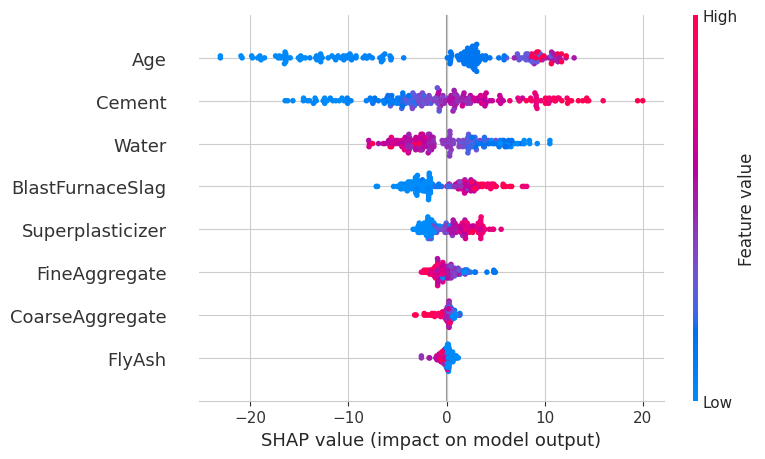

In [14]:
explainer = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("../docs/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia SHAP (media |valor|)": np.abs(shap_values).mean(axis=0)
}).sort_values("Importancia SHAP (media |valor|)", ascending=False)

importances

,Variable,Importancia SHAP (media |valor|)
7,Age,8.134449
0,Cement,5.818467
3,Water,3.570618
1,BlastFurnaceSlag,2.830430
4,Superplasticizer,1.897208
6,FineAggregate,1.021970
5,CoarseAggregate,0.496582
2,FlyAsh,0.372709


## 9. Conclusiones preliminares (T2)

- Ambos modelos de ML se evalúan con protocolo reproducible (80/20 holdout,
  5-fold CV, `random_state=42`).
- Se cuantifica la ganancia de precisión frente al método empírico ACI 211.1 /
  Abrams, respondiendo directamente la observación del docente sobre el aporte
  del proyecto frente a Yeh (1998) y Chou et al. (2011).
- El análisis SHAP identifica qué variables pesan más en la predicción,
  información que se desarrollará con mayor profundidad en T3 junto con
  recomendaciones de dosificación por rango de resistencia.